Accuracy: 0.8641304347826086
Confusion Matrix:
 [[65 16]
 [ 9 94]]


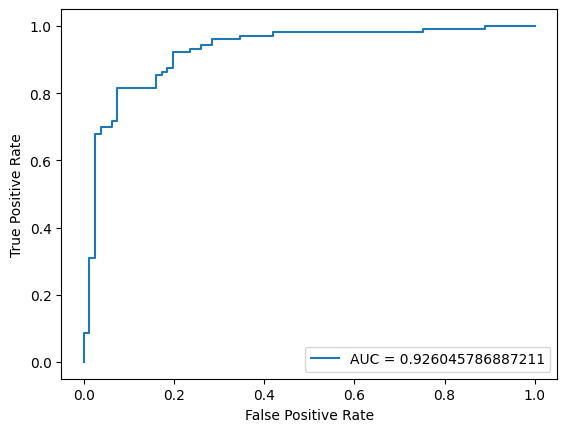

Feature Importance:
 0     2.045615
6     0.548595
5     0.483151
7     0.459055
17    0.390602
21    0.364436
18    0.360584
3     0.170391
14    0.161070
2     0.111823
1     0.010794
4     0.010371
16   -0.037669
15   -0.040890
19   -0.050655
20   -0.097144
9    -0.145803
13   -0.238670
12   -0.541708
11   -0.698525
8    -1.002673
10   -1.562677
dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("heart_disease_uci.csv")

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

y = (y > 0).astype(int)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

importance = pd.Series(model.coef_[0])
print("Feature Importance:\n", importance.sort_values(ascending=False))







